In [39]:
import pandas as pd

# File paths
file_paths = [
    "2022.01_WAVES-ACCESS-RECORDS.csv",
    "2022.02_WAVES-ACCESS-RECORDS.csv",
    "2022.03_WAVES-ACCESS-RECORDS-.csv", 
    "2022.04_WAVES-ACCESS-RECORDS.csv",
    "2022.05-WAVES-ACCESS-RECORDS.csv"
]

# Load a sample from each dataset to inspect structure
samples = {path: pd.read_csv(path, nrows=5) for path in file_paths}

# Display the first few rows of each dataset
samples


{'2022.01_WAVES-ACCESS-RECORDS.csv':    NAMELAST    NAMEFIRST NAMEMID     UIN    BDGNBR ACCESS_TYPE  \
 0    MALLEY       ROBERT       N  U38641  183020.0          VA   
 1    FARLEY  CHRISTOPHER       B  U38643       NaN          VA   
 2  KALAMBUR        GUHAN       R  U38636  176380.0          VA   
 3   KUKLISH      MATILDA       N  U38642  178294.0          VA   
 4    SIERRA       RONNEY       F  U38598       NaN          VA   
 
               TOA  POA  TOD  POD  ...    LASTENTRYDATE TERMINAL_SUFFIX  \
 0  1/1/2022 12:22  NaN  NaN  B04  ...  12/31/2021 1:54              PR   
 1             NaN  NaN  NaN  NaN  ...    1/2/2022 9:03              RF   
 2  1/2/2022 10:59  NaN  NaN  B04  ...  12/30/2021 4:27              SF   
 3  1/2/2022 14:01  NaN  NaN  B04  ...  12/31/2021 3:03              AT   
 4             NaN  NaN  NaN  NaN  ...  12/27/2021 4:04              CK   
 
   VISITEE_NAMELAST  VISITEE_NAMEFIRST  MEETING_LOC MEETING_ROOM  \
 0         Rajgopal              Pavan  

In [41]:
# Load and clean datasets
def load_and_clean(filepath):
    df = pd.read_csv(filepath)
    
    # Convert date columns to datetime format
    date_cols = ['TOA', 'LASTENTRYDATE']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # Select relevant columns
    df = df[['TOA', 'LASTENTRYDATE', 'ACCESS_TYPE', 'MEETING_LOC', 'MEETING_ROOM']]
    
    return df

# Process all files
dataframes = [load_and_clean(fp) for fp in file_paths]

# Combine into one DataFrame
df_combined = pd.concat(dataframes, ignore_index=True)

# Display summary
df_combined.info(), df_combined.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43034 entries, 0 to 43033
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TOA            28721 non-null  datetime64[ns]
 1   LASTENTRYDATE  43034 non-null  datetime64[ns]
 2   ACCESS_TYPE    43034 non-null  object        
 3   MEETING_LOC    43034 non-null  object        
 4   MEETING_ROOM   43033 non-null  object        
dtypes: datetime64[ns](2), object(3)
memory usage: 1.6+ MB


(None,
                   TOA       LASTENTRYDATE ACCESS_TYPE MEETING_LOC MEETING_ROOM
 0 2022-01-01 12:22:00 2021-12-31 01:54:00          VA          WH       WW-132
 1                 NaT 2022-01-02 09:03:00          VA          WH       WW G47
 2 2022-01-02 10:59:00 2021-12-30 04:27:00          VA        OEOB           97
 3 2022-01-02 14:01:00 2021-12-31 03:03:00          VA          WH         WHSR
 4                 NaT 2021-12-27 04:04:00          VA        OEOB           97)

/var/folders/_9/2vrs5s614flg6q_4wbdxnskw0000gn/T/ipykernel_70583/2111886071.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=access_counts.index, y=access_counts.values, palette="Blues_r")


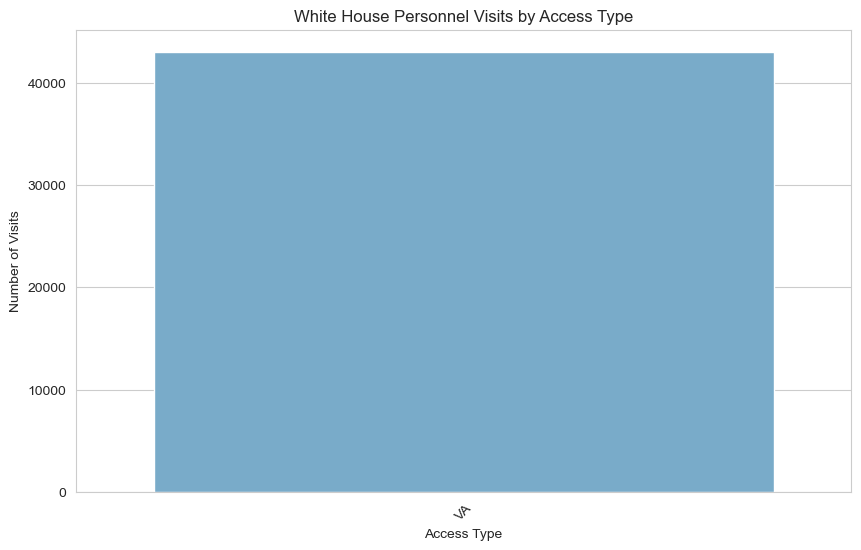

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Count occurrences of each access type
access_counts = df_combined['ACCESS_TYPE'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=access_counts.index, y=access_counts.values, palette="Blues_r")

# Labels and title
plt.xlabel("Access Type")
plt.ylabel("Number of Visits")
plt.title("White House Personnel Visits by Access Type")
plt.xticks(rotation=45)
plt.show()


<Figure size 1200x600 with 0 Axes>

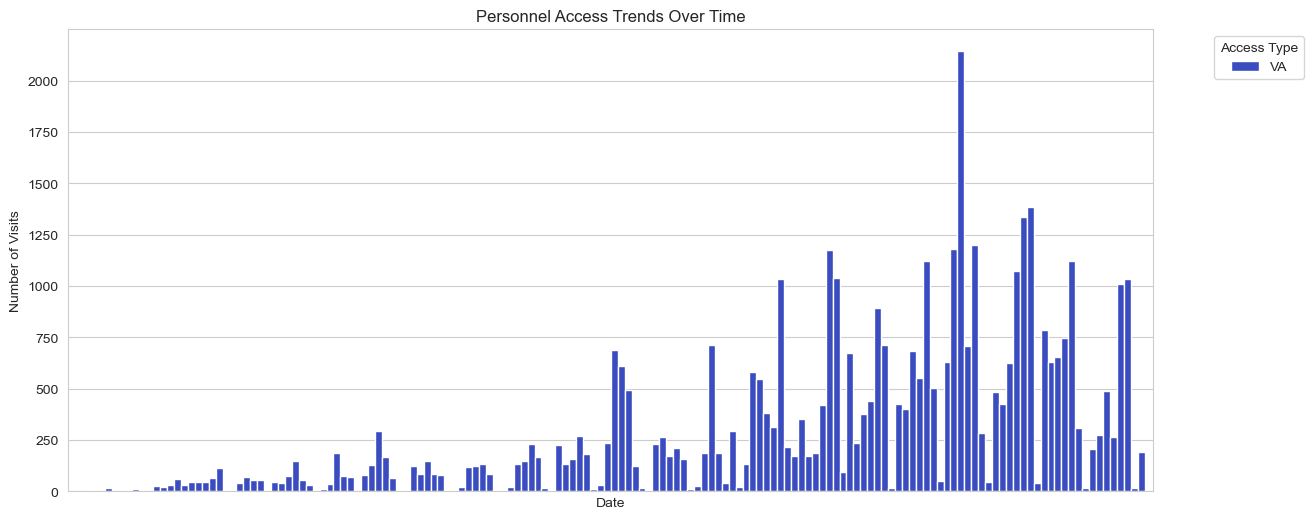

In [45]:
# Extract date from TOA (fallback to LASTENTRYDATE if TOA is missing)
df_combined['DATE'] = df_combined['TOA'].dt.date.fillna(df_combined['LASTENTRYDATE'].dt.date)

# Group by date and access type
access_over_time = df_combined.groupby(['DATE', 'ACCESS_TYPE']).size().unstack().fillna(0)

# Plot stacked bar chart
plt.figure(figsize=(12, 6))
access_over_time.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(14, 6), width=1.0)

# Labels and title
plt.xlabel("Date")
plt.ylabel("Number of Visits")
plt.title("Personnel Access Trends Over Time")
plt.xticks([])  # Hide x-axis labels for clarity
plt.legend(title="Access Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


/var/folders/_9/2vrs5s614flg6q_4wbdxnskw0000gn/T/ipykernel_70583/1067778713.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=access_counts.index, y=access_counts.values, palette="Blues_r")


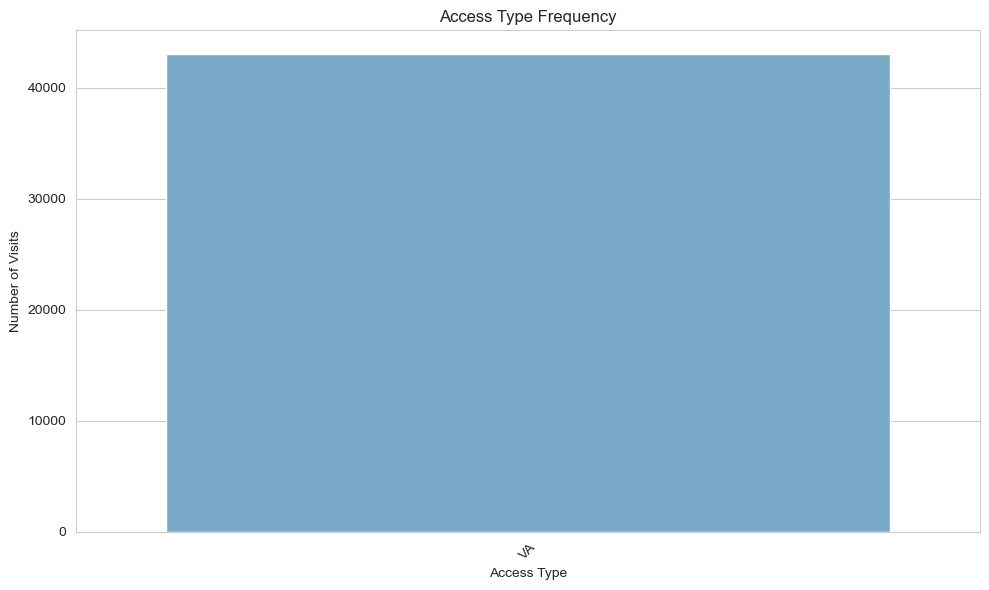

/var/folders/_9/2vrs5s614flg6q_4wbdxnskw0000gn/T/ipykernel_70583/1067778713.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=room_counts.index, y=room_counts.values, palette="viridis")


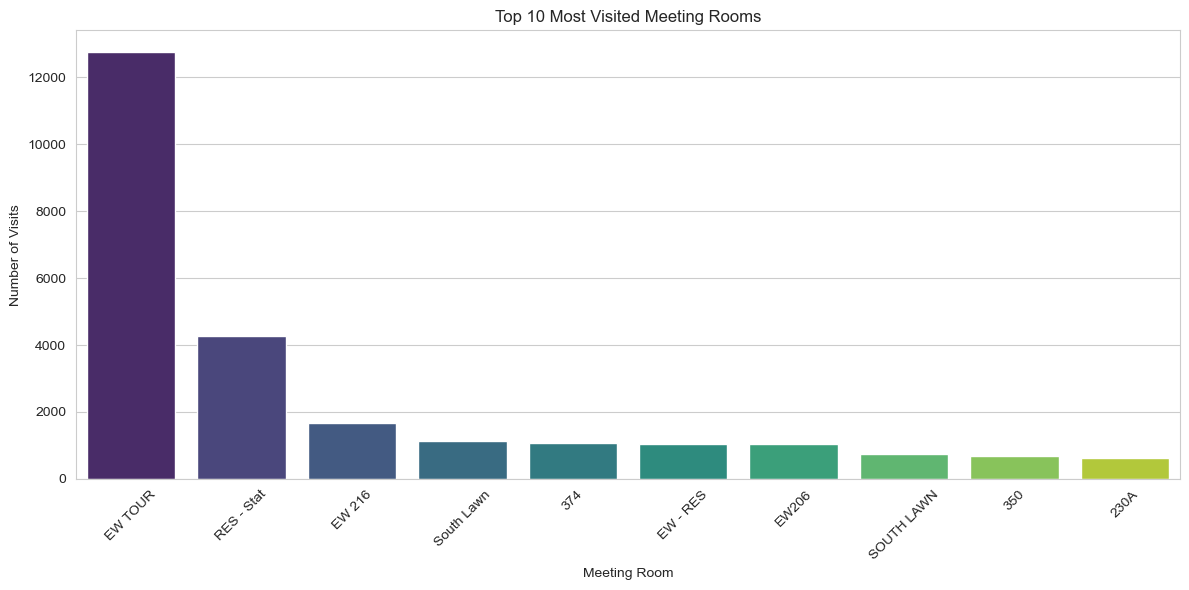

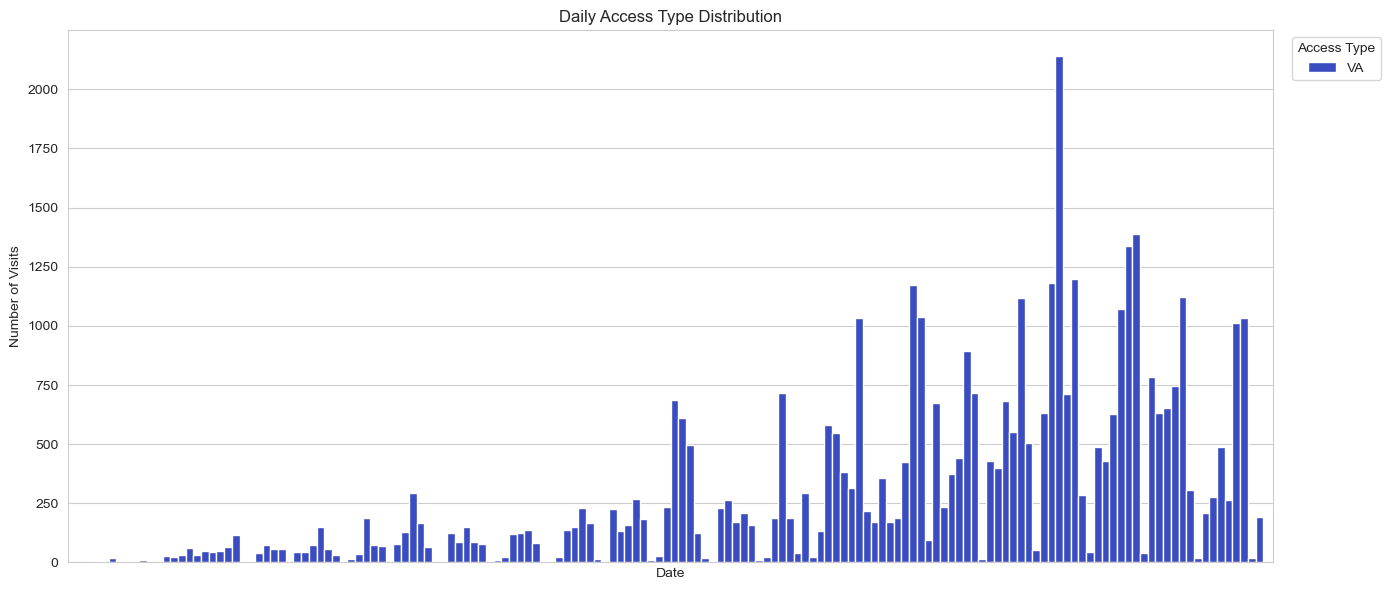

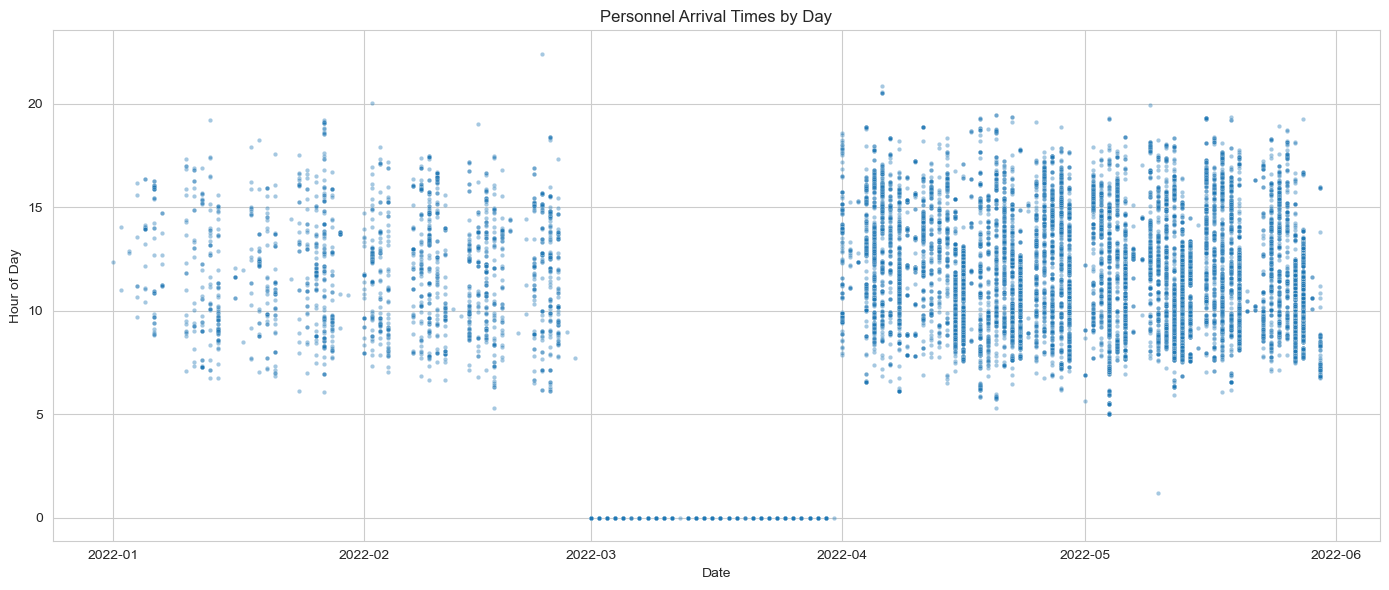

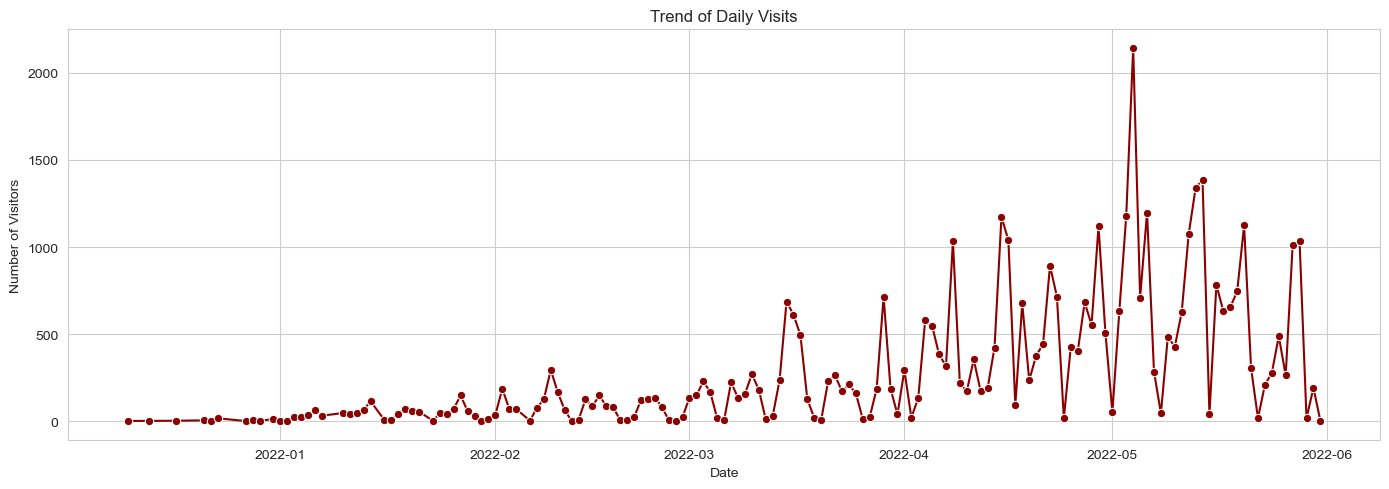

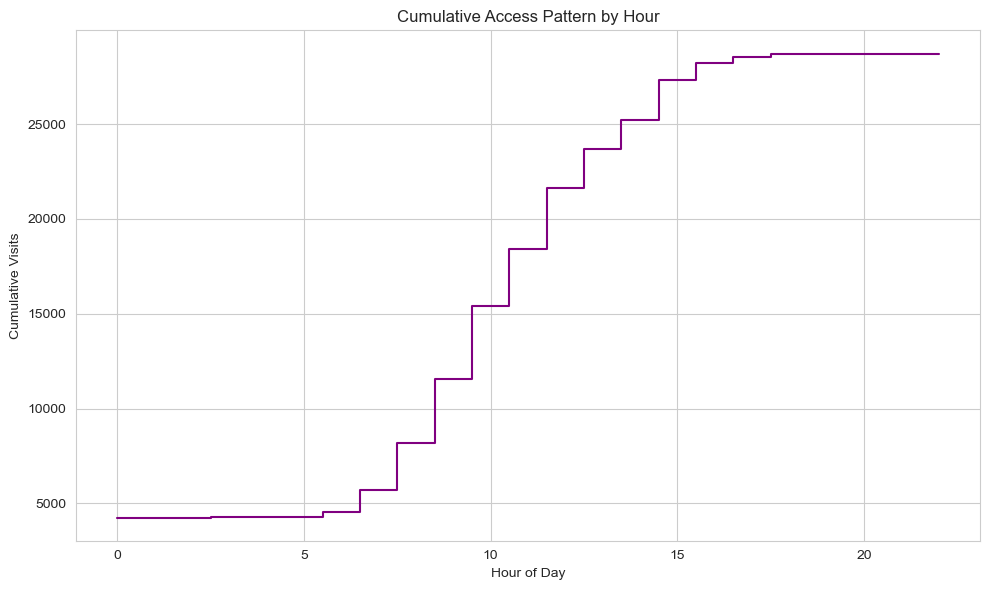

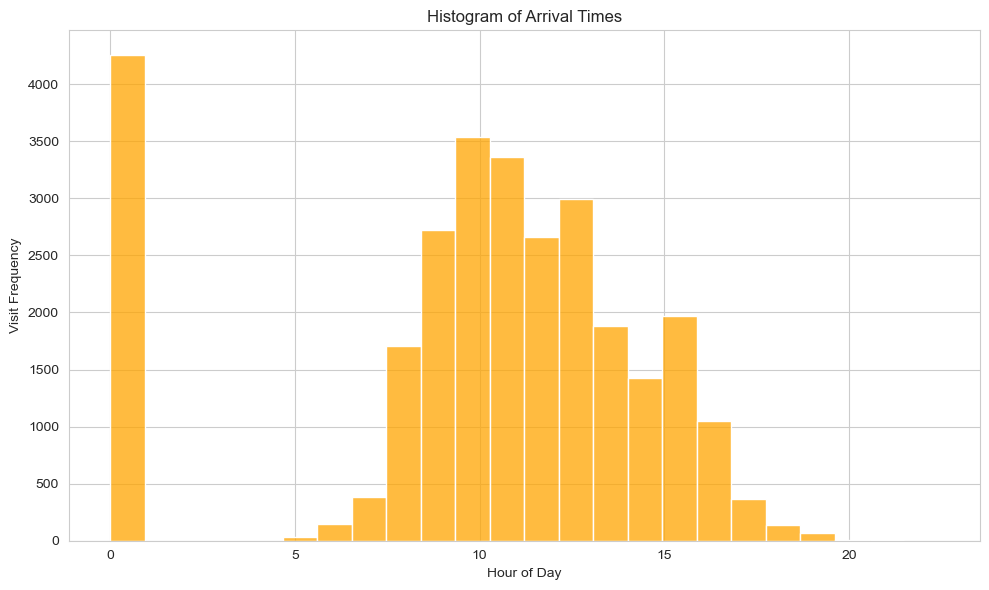

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = [
    "2022.01_WAVES-ACCESS-RECORDS.csv",
    "2022.02_WAVES-ACCESS-RECORDS.csv",
    "2022.03_WAVES-ACCESS-RECORDS-.csv", 
    "2022.04_WAVES-ACCESS-RECORDS.csv",
    "2022.05-WAVES-ACCESS-RECORDS.csv"
]

# Load and clean datasets
def load_and_clean(filepath):
    df = pd.read_csv(filepath)
    date_cols = ['TOA', 'LASTENTRYDATE']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df = df[['TOA', 'LASTENTRYDATE', 'ACCESS_TYPE', 'MEETING_LOC', 'MEETING_ROOM']]
    return df

# Combine datasets
dataframes = [load_and_clean(fp) for fp in file_paths]
df_combined = pd.concat(dataframes, ignore_index=True)

# Fallback for missing TOA
df_combined['DATE'] = df_combined['TOA'].dt.date.fillna(df_combined['LASTENTRYDATE'].dt.date)

# Filter null dates
df_combined = df_combined[df_combined['DATE'].notna()]

# Set plot style
sns.set_style("whitegrid")

# ----------------------------------------
# 1. Bar Chart – Number of visits by access type
# ----------------------------------------
plt.figure(figsize=(10, 6))
access_counts = df_combined['ACCESS_TYPE'].value_counts()
sns.barplot(x=access_counts.index, y=access_counts.values, palette="Blues_r")
plt.xlabel("Access Type")
plt.ylabel("Number of Visits")
plt.title("Access Type Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2. Column Chart – Number of visits by meeting room
# ----------------------------------------
plt.figure(figsize=(12, 6))
room_counts = df_combined['MEETING_ROOM'].value_counts().head(10)
sns.barplot(x=room_counts.index, y=room_counts.values, palette="viridis")
plt.xlabel("Meeting Room")
plt.ylabel("Number of Visits")
plt.title("Top 10 Most Visited Meeting Rooms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------------------
# 3. Stacked Bar with Time – Access type by date
# ----------------------------------------
access_over_time = df_combined.groupby(['DATE', 'ACCESS_TYPE']).size().unstack().fillna(0)
access_over_time.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(14, 6), width=1.0)
plt.xlabel("Date")
plt.ylabel("Number of Visits")
plt.title("Daily Access Type Distribution")
plt.legend(title="Access Type", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks([])
plt.tight_layout()
plt.show()

# ----------------------------------------
# 4. Scatterplot with Time – Time of Arrival distribution
# ----------------------------------------
plt.figure(figsize=(14, 6))
valid_times = df_combined[df_combined['TOA'].notna()]
sns.scatterplot(x=valid_times['TOA'].dt.date, y=valid_times['TOA'].dt.hour + valid_times['TOA'].dt.minute / 60,
                alpha=0.4, s=10)
plt.xlabel("Date")
plt.ylabel("Hour of Day")
plt.title("Personnel Arrival Times by Day")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 5. Line Chart – Daily number of visitors
# ----------------------------------------
daily_counts = df_combined.groupby('DATE').size()
plt.figure(figsize=(14, 5))
sns.lineplot(x=daily_counts.index, y=daily_counts.values, marker='o', color='darkred')
plt.xlabel("Date")
plt.ylabel("Number of Visitors")
plt.title("Trend of Daily Visits")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 6. Step Chart – Cumulative visits per hour of the day
# ----------------------------------------
df_combined['HOUR'] = df_combined['TOA'].dt.hour
hourly_counts = df_combined.groupby('HOUR').size().sort_index()
cumulative_counts = hourly_counts.cumsum()
plt.figure(figsize=(10, 6))
plt.step(cumulative_counts.index, cumulative_counts.values, where='mid', color='purple')
plt.xlabel("Hour of Day")
plt.ylabel("Cumulative Visits")
plt.title("Cumulative Access Pattern by Hour")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 7. Histogram – Visit time distribution (optional 7th visual)
# ----------------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(valid_times['TOA'].dt.hour + valid_times['TOA'].dt.minute / 60, bins=24, kde=False, color='orange')
plt.xlabel("Hour of Day")
plt.ylabel("Visit Frequency")
plt.title("Histogram of Arrival Times")
plt.tight_layout()
plt.show()
